# **Projet : Prédiction du nutriscore**
**Module : Machine Learning**


**Groupe : Ameth SYLLA & Ziyad BERJAN**


**Professeur : Dr Nicola ROCHET**

**Établissement : Aix Ynov Campus**


**Date : Mai 2026**


# **Introduction**
Le **Nutri-Score** est devenu un outil de santé publique incontournable en Europe. Ce système d'étiquetage nutritionnel, basé sur un logo allant du vert (A) au rouge (E), a pour but de fournir aux consommateurs une information lisible et rapide sur la qualité nutritionnelle des produits. En calculant un score qui pondère les nutriments à favoriser (fibres, protéines, fruits et légumes) et ceux à limiter (calories, acides gras saturés, sucres, sel), il joue un rôle crucial dans la prévention des maladies liées à l'alimentation et incite les industriels à améliorer leurs recettes.

Pour mener à bien ce projet de modélisation, nous nous appuyons sur la base de données **OpenFoodFacts**. Véritable "Wikipédia de l'alimentation", ce projet collaboratif open data contient des informations sur plus de 4 millions de produits à travers le monde. Son dataset est extrêmement riche : il regroupe des informations d'identité (nom, marque), des données taxonomiques (catégories) ainsi que des compositions nutritionnelles détaillées pour chaque produit, offrant ainsi une base d'apprentissage massive pour le Machine Learning.

L'**objectif principal** de notre étude est de développer un modèle prédictif capable d'estimer avec précision le Nutri-Score d'un produit alimentaire en utilisant exclusivement ses informations nutritionnelles. Une telle solution permettrait, par exemple, d'estimer la qualité d'un nouveau produit en cours de formulation ou de combler les lacunes d'étiquetage sur certains marchés.

Notre **approche technique** se distingue par l'exploitation des deux indicateurs présents dans le dataset d'OpenFoodFacts :
- **Nutri-Score Score (Valeur numérique) :** Cette colonne représente le résultat brut du calcul algorithmique (généralement compris entre -15 et +40). Nous l'utilisons pour une approche par **régression**, visant une précision fine de la valeur continue.
- **Nutri-Score Grade (Catégorie) :** Cette colonne représente la lettre finale (A, B, C, D ou E). Elle est utilisée pour une approche par **classification**.

En travaillant sur ces deux axes, nous serons en mesure de confronter nos résultats : d'un côté la prédiction d'une valeur précise, et de l'autre la classification dans une catégorie, afin de déterminer quelle méthode offre la meilleure fiabilité pour l'évaluation nutritionnelle automatisée.

## **Plan Général**
 ### **I. Approche par Régression**  
 **I.1. Analyse Exploratoire**  
 **I.1.1. Chargement du dataset**  
 **I.1.2. Analyse des valeurs manquantes**  
 **I.1.3. Analyse des outliers**  
 **I.2. Pipline de nettoyage**  
  **I.2.1. Gestion des outliers**  
 **I.2.2. Imputation des valaeurs manquantes**  
  **I.2.3. Elimination des doublons**  
 **I.3. Modélisation et Optimisation**  
 **I.3.1. Baseline Random Forest**  
 **I.3.2. Optimisation avec Optuna**  


-------

### **II. Approche par Classification**  
    Cette partie est dédiée à la prédiction de la catégorie qualitative `nutriscore_grade` (A, B, C, D, E), traitant le problème comme une classification multi-classe.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math


### **I.1. Analyse Exploratoire**
Cette phase initiale est cruciale pour appréhender la structure du dataset OpenFoodFacts, qui présente un volume massif de plus de 4,4 millions de lignes pour 210 colonnes. L’objectif est de parcourir les données, de les comprendre afin de pouvoir decider de la stratégie de traitement à appliquer.

#### **I.1.1. Chargement du dataset**  
La première étape consiste à charger un échantillon de 100 000 lignes directement depuis la source compressée d'OpenFoodFacts. Ce premier aperçu permet de constater la complexité du jeu de données brut, qui comporte initialement plus de 200 colonnes incluant des informations très diverses (données logistiques, URLs d'images, indicateurs de packaging). Ce chargement initial sans filtrage de colonnes est essentiel pour observer la structure native du fichier, vérifier les séparateurs de texte et identifier les colonnes contenant un fort taux de données manquantes ou des types de données incohérents avant d'engager une phase de sélection plus stricte.

In [3]:
url = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"

raw_df = pd.read_csv(url, sep='\t', low_memory=False, nrows=100000)
raw_df

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1714301721,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,21140212214,http://world-en.openfoodfacts.org/product/0021...,usda-ndb-import,1489094196,2017-03-09T21:16:36Z,1740273886,2025-02-23T01:24:46Z,NaN,1740273886,2025-02-23T01:24:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99996,21140212221,http://world-en.openfoodfacts.org/product/0021...,usda-ndb-import,1489094197,2017-03-09T21:16:37Z,1740273890,2025-02-23T01:24:50Z,NaN,1740273890,2025-02-23T01:24:50Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99997,21140212368,http://world-en.openfoodfacts.org/product/0021...,org-database-usda,1587643456,2020-04-23T12:04:16Z,1587643456,2020-04-23T12:04:16Z,org-database-usda,1734787989,2024-12-21T13:33:09Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99998,21140212382,http://world-en.openfoodfacts.org/product/0021...,usda-ndb-import,1489059201,2017-03-09T11:33:21Z,1740273893,2025-02-23T01:24:53Z,NaN,1740273893,2025-02-23T01:24:53Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Afin d'optimiser l'efficacité du modèle et de réduire la complexité computationnelle, une sélection ciblée des variables a été opérée parmi les 210 colonnes disponibles. Ce sous-ensemble se divise en trois catégories : les variables explicatives (features), comprenant les huit nutriments fondamentaux dont les teneurs pour 100g impactent directement le calcul biologique du score (énergie, graisses totales et saturées, sucres, fibres, protéines, glucides et sel) ; la variable cible (target), le nutriscore_score ; et enfin la colonne product_name, conservée spécifiquement pour permettre des analyses sémantiques ultérieures sur la nomenclature des produits

In [33]:
# les colonnes qui vont nous interesser
nutri_cols = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g', 
    'sugars_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g',
    'salt_100g'
]

identity_cols = ['product_name']

target = ['nutriscore_score']

cols = nutri_cols + target + identity_cols

**Chargement itératif par blocs (Chunking)**


Pour traiter efficacement le volume massif de données sans dépasser les capacités de la mémoire vive, une stratégie de chargement par blocs (chunking) a été mise en œuvre à l'aide de l'itérateur reader de Pandas. En fixant un chunksize à 100 000 lignes, le dataset est fractionné en segments gérables, permettant d'appliquer les opérations de filtrage et de nettoyage de manière séquentielle. L'utilisation de l'indice d'itération i offre une flexibilité totale, permettant d'interrompre le processus à n'importe quel bloc (par exemple, après le traitement de 300 000 lignes) pour valider la logique de la pipeline avant un déploiement global. Une fois les blocs extraits et pré-nettoyés, ils sont agrégés via pd.concat pour former un DataFrame de travail cohérent et optimisé, ne contenant que les colonnes préalablement sélectionnées.

In [ ]:
reader = pd.read_csv(
        url, compression='gzip', sep='\t',
        on_bad_lines='skip', chunksize=100000,
        low_memory=False, usecols=cols
    )

chunks = []
for i, chunk in enumerate(reader):
    print(f"Traitement du bloc n°{i} (lignes {i*reader.chunksize} à {(i+1)*reader.chunksize})")
    chunks.append(chunk)
    if i == 2: 
        break

df = pd.concat(chunks)
df


#### **I.1.2. Analyse des valeurs manquantes**  


Une fois le jeu de données restreint chargé, une analyse statistique de la parcimonie (sparsity) est effectuée pour quantifier la proportion de valeurs manquantes (NaN) au sein des colonnes sélectionnées. Cette étape est réalisée via la fonction plot_missing_values, qui calcule le pourcentage de vide par variable et génère une visualisation sous forme de diagramme à barres pour toutes les colonnes dépassant un seuil critique (fixé ici à 2 %). Cette analyse est déterminante pour valider la qualité du signal nutritionnel disponible : elle permet d'identifier les nutriments qui, par leur faible taux de remplissage, pourraient introduire un biais significatif dans le modèle de régression. Les résultats obtenus ici guident directement le choix de la stratégie d'imputation ultérieure, visant à arbitrer entre la suppression des lignes incomplètes et le remplacement des valeurs manquantes par des zéros.


In [36]:
def plot_missing_values(df, threshold=2):
    """
    Calcule et affiche le pourcentage de NaNs par colonne au-delà d'un seuil.
    """
    # Calcul des pourcentages
    percent_missing = df.isnull().sum() * 100 / len(df)
    
    # Filtrage selon le seuil
    filtered = percent_missing[percent_missing > threshold].sort_values(ascending=False)
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=filtered.values, y=filtered.index, hue=filtered.index, palette='viridis', legend=False)
    
    ax.set_title(f"Colonnes avec > {threshold}% de valeurs manquantes des {len(df)} premieres lignes")
    ax.set_xlabel("Pourcentage de NaNs (%)")
    plt.tight_layout()
    
    return ax

<Axes: title={'center': 'Colonnes avec > 2% de valeurs manquantes des 300000 premieres lignes'}, xlabel='Pourcentage de NaNs (%)', ylabel='None'>

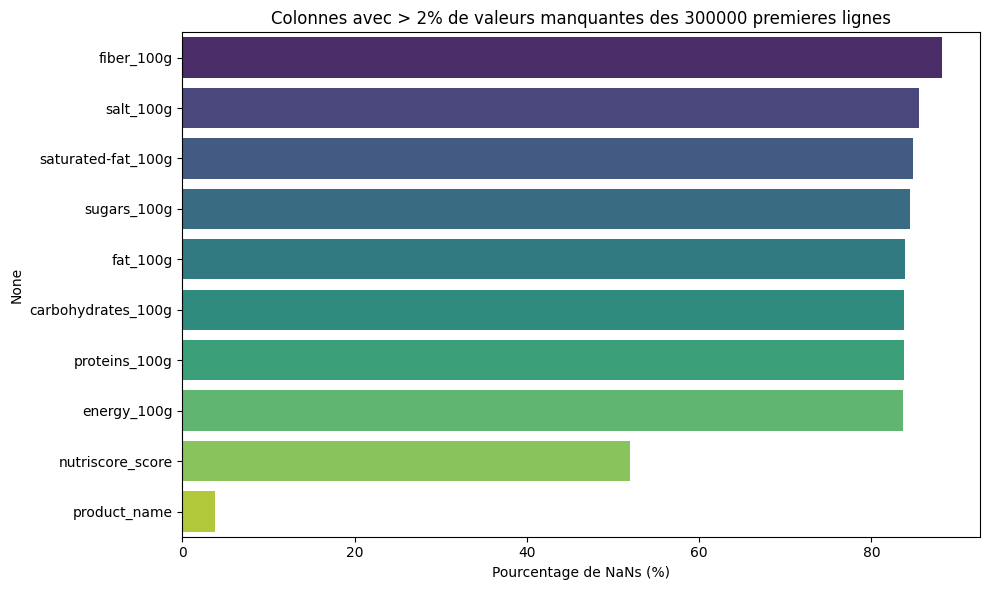

In [37]:
plot_missing_values(df)

L'analyse visuelle de la complétude sur les 300 000 premières lignes révèle une **parcimonie extrême** des données nutritionnelles. Les points clés de cette analyse sont les suivants :

*   **Variables nutritionnelles critiques :** La quasi-totalité des colonnes de nutriments (`fiber_100g`, `salt_100g`, `fat_100g`, etc.) affiche un taux de valeurs manquantes alarmant, oscillant entre **82 % et près de 90 %**. Cela signifie que moins de deux produits sur dix disposent d'informations nutritionnelles complètes dans ce segment initial.
*   **Variable cible (`nutriscore_score`) :** Environ **52 %** des lignes ne possèdent pas de Nutri-Score renseigné. Cette lacune est critique car elle limite directement le volume de données disponibles pour l'entraînement d'un modèle supervisé.
*   **Variable d'identité (`product_name`) :** C'est la colonne la mieux renseignée avec seulement **4 %** de valeurs manquantes, confirmant son utilité pour le suivi des produits.

Ce constat impose un arbitrage. Une suppression pure et simple des lignes contenant des `NaN` réduirait le dataset à un volume trop faible pour une première itération. Par conséquent, une stratégie d'**imputation par zéro** pour les nutriments est adoptée afin de préserver la masse de données, tout en étant conscient du bruit important que cela introduira dans le modèle.

#### **I.1.3. Analyse des outliers**  

la fonction plot_outlier utilise des boxplots pour identifier visuellement les données s'écartant de manière irréaliste des normes physiques.

Afin de gérer l'hétérogénéité des échelles, une échelle logarithmique est spécifiquement appliquée à la variable energy_100g pour compenser des écarts extrêmes constatés dans les données brutes, où certaines valeurs dépassent largement les limites biologiques. Cette visualisation permet de confirmer la pertinence des futurs seuils de filtrage (ex: plafonnement à 100g pour les nutriments) en mettant en évidence les points de données qui pollueraient l'apprentissage de la régression.

In [ ]:
def plot_outlier(df_clean):        
    n_cols = 3
    n_rows = math.ceil(len(nutri_cols) / n_cols)

    plt.figure(figsize=(15, 5 * n_rows))

    for i, nut in enumerate(nutri_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(y=nut, data=df_clean, palette='Set2')
        plt.title(f'Distribution de {nut}')
        
        # Échelle logarithmique pour l'énergie car les écarts sont extrêmes
        if nut == 'energy_100g':
            plt.yscale('log')
        
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and s

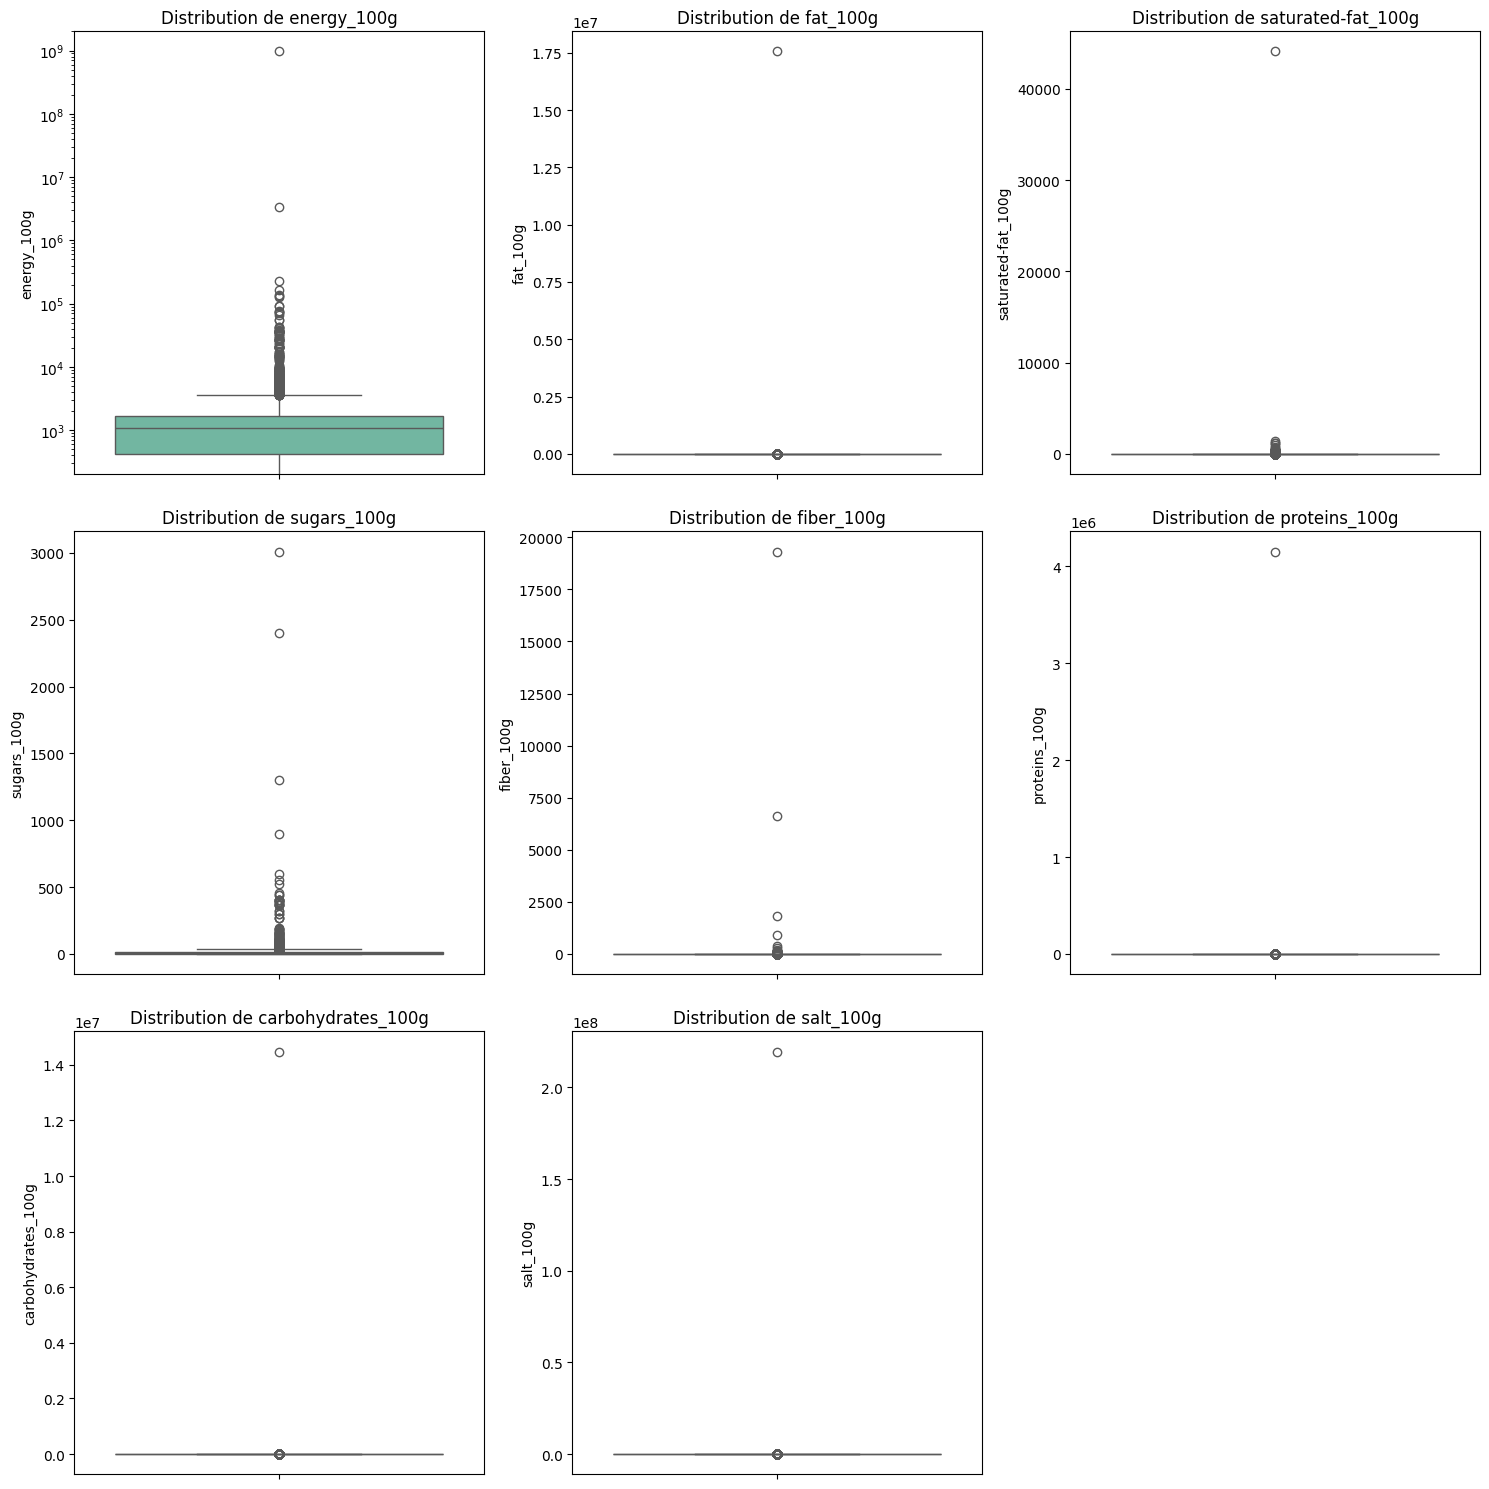

In [38]:
plot_outlier(df)

L'examen visuel des variables nutritionnelles met en évidence des anomalies majeures :
*   **Énergie (`energy_100g`) :** Même avec une échelle logarithmique, on observe des points atteignant **10⁹ kJ**. À titre de comparaison, la valeur énergétique maximale physiquement possible (pure graisse) est d'environ 3 700 kJ pour 100g.
*   **Nutriments (g/100g) :** Les variables comme `fat_100g`, `carbohydrates_100g` ou `salt_100g` présentent des valeurs s'élevant à **10⁷** ou **10⁸**. Or, la somme de tous les nutriments ne peut excéder la masse totale du produit, soit **100g**.
*   **Impact sur la boîte :** La présence de ces "méga-outliers" écrase complètement les boîtes à moustaches au bas de l'axe des ordonnées, rendant la médiane et les quartiles invisibles à l'œil nu sur une échelle linéaire.

Face à ces erreurs de saisie manifestes, des filtres de nettoyage seront instaurés pour garantir l'intégrité physique des données


### **I.1. Pipline de nettoyage**

Le traitement des données repose sur la mise en place d'un enchainement d'action ecapsule dans la fonction `clean_df`. Cette étape transforme les observations issues de l'analyse exploratoire en règles de gestion systématiques afin d'assainir le jeu de données final. La pipeline s'articule autour de trois axes correctifs : une gestion des outliers par l'application de filtres de réalisme physique sur les nutriments et l'énergie, une imputation des valeurs manquantes visant à substituer les données lacunaires par des constantes déterminées, et une élimination des doublons.

**I.2.1. Gestion des outliers**  
La détection des valeurs aberrantes s'appuie sur des contraintes biologiques et physiques strictes afin d'éliminer le bruit généré par les erreurs de saisie manuelle dans OpenFoodFacts. Pour les variables nutritionnelles (masses), un filtre est appliqué pour ne conserver que les valeurs comprises entre 0 et 100g pour 100g de produit. Concernant la densité énergétique, le seuil maximal est fixé à 4000 kJ, excluant ainsi les valeurs physiquement impossibles tout en préservant les produits à forte teneur lipidique. Enfin, la variable cible nutriscore_score est filtrée pour respecter l'échelle légale allant de -15 à +40. Cette étape garantit que le modèle de régression s'entraîne sur des relations nutritionnelles cohérentes.


**I.2.2. Imputation des valaeurs manquantes**  
Dans cette première itération, une stratégie d'imputation par zéro a été adoptée pour l'ensemble des colonnes nutritionnelles. Bien que simpliste, ce choix permet de maximiser la taille du jeu de données en évitant la suppression massive de lignes incomplètes révélée lors de l'analyse du vide. Pour la colonne product_name, les valeurs manquantes sont remplacées par le label "Unknown Product" afin de maintenir l'intégrité de la structure du DataFrame sans perdre d'échantillons. Cette approche vise à établir une "baseline" de performance sur un volume de données important avant d'envisager des méthodes d'imputation statistique plus complexes.


**I.2.3. Elimination des doublons**  
L'intégrité du dataset est finalisée par un processus de déduplication systématique. En supprimant les entrées répétées, on évite le sur-apprentissage (overfitting) lié à la présence multiple d'un même échantillon dans le jeu d'entraînement. Cette étape assure que chaque observation contribue de manière unique et équitable à la construction du modèle de forêt aléatoire.




In [41]:
def clean_df(df_raw, target='nutriscore_score'):
    df = df_raw.copy()
    
    # 1. Conversion et nettoyage de la TARGET en INT
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df = df.dropna(subset=[target])
    df[target] = df[target].astype(int)

    # Filtre de réalisme pour le score cible (-15 à +40)
    df = df[(df[target] >= -15) & (df[target] <= 40)]
    
    # 2. Conversion et filtrage des colonnes nutritionnelles
    for col in nutri_cols:
        if col in df.columns:
            # Conversion en float pour les décimales
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
            # Application des filtres d'outliers (on ne drop pas encore les NaNs ici)
            if col != 'energy_100g':
                # On garde les valeurs valides (0-100) OU les NaNs pour imputation ultérieure
                df = df[(df[col].isna()) | ((df[col] >= 0) & (df[col] <= 100))]
            else:
                # Filtre spécifique énergie < 4000 kJ[cite: 2]
                df = df[(df[col].isna()) | ((df[col] >= 0) & (df[col] < 4000))]

    # Conversion, suppression des NaNs et passage en entier pour la TARGET
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df = df.dropna(subset=[target])
    df[target] = df[target].astype(int) 
    
    # 3. Traitement spécifique de 'product_name' si présent
    if 'product_name' in df.columns:
        df['product_name'] = df['product_name'].fillna('Unknown Product')

    # 4. Imputation finale des valeurs manquantes par 0 pour les colonnes numériques
    # On cible uniquement les colonnes nutritionnelles présentes
    cols_to_fix = [c for c in nutri_cols if c in df.columns]
    df[cols_to_fix] = df[cols_to_fix].fillna(0)
        
    return df

In [42]:
# Utilisation :
df_clean = clean_df(df)

In [43]:
df_clean

,product_name,nutriscore_score,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
12,granola Bio le Chocolaté,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
13,Unknown Product,6,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
14,xytitol pastilles,-11,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
18,Powdered peanut butter,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
19,Madeleines ChocoLait,20,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
299981,Assortiment de barres glacées,6,427.857143,5.000000,3.571429,12.857143,10.000000,0.0,1.428571,0.107143
299988,Ice cream Oreo chocolate,6,480.800000,4.000000,2.800000,17.600000,13.600000,0.8,1.600000,0.140000
299989,Nestle Drumstick Vanilla and Caramel,16,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
299990,Parlour fraise,6,360.638298,2.659574,2.393617,14.361702,11.170213,0.0,1.063830,0.106383


Axes(0.0467222,0.0971296;0.927278x0.840648)


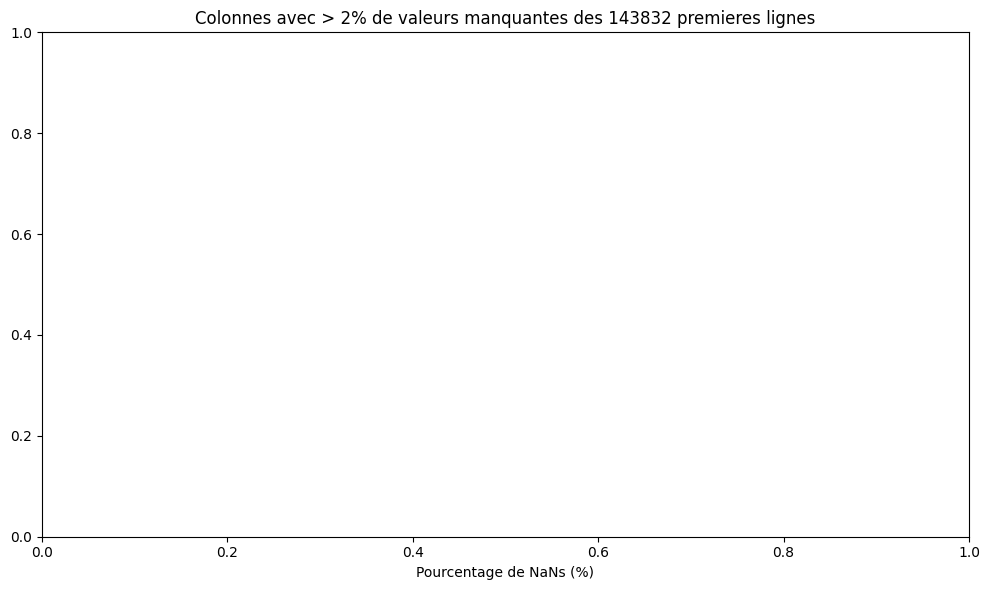

In [44]:
print(plot_missing_values(df_clean))

In [ ]:
def process_full_dataset(url, cols, chunk_size=100000):
    # INITIALISATION DU READER MANQUANTE
    reader = pd.read_csv(
        url, compression='gzip', sep='\t',
        on_bad_lines='skip', chunksize=chunk_size,
        low_memory=False, usecols=cols
    )
    
    clean_chunks = []
    print("Début du traitement des données par blocs...")

    for i, chunk in enumerate(reader):
        # 1. Nettoyage des valeurs aberrantes
        # On passe explicitement le nom de la cible
        chunk_clean= clean_df(chunk, target='nutriscore_score')
        
        clean_chunks.append(chunk_clean)
        
        if i % 5 == 0:
            print(f"Bloc {i} terminé. Taille actuelle cumulée : {sum(len(c) for c in clean_chunks)}")

    print("Fusion des blocs en cours...")
    df_final = pd.concat(clean_chunks, ignore_index=True)

    count = df_final.duplicated().sum()
    print(f"Nombre de doublons détectés : {count}")
    df_final.drop_duplicates()
    
    print("-" * 30)
    print(f"Traitement terminé avec succès. Lignes finales : {len(df_final)}")
    
    return df_final

In [49]:
df_cleaned = process_full_dataset(url, cols)

Début du traitement des données par blocs...
Bloc 0 terminé. Taille actuelle cumulée : 45078
Bloc 5 terminé. Taille actuelle cumulée : 255195
Bloc 10 terminé. Taille actuelle cumulée : 366091
Bloc 15 terminé. Taille actuelle cumulée : 486965
Bloc 20 terminé. Taille actuelle cumulée : 716859
Bloc 25 terminé. Taille actuelle cumulée : 862667
Bloc 30 terminé. Taille actuelle cumulée : 986767
Bloc 35 terminé. Taille actuelle cumulée : 1099308
Bloc 40 terminé. Taille actuelle cumulée : 1276475
Fusion des blocs en cours...
------------------------------
Traitement terminé avec succès. Lignes finales : 1361794


In [52]:
df_cleaned

,product_name,nutriscore_score,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,granola Bio le Chocolaté,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1,Unknown Product,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2,xytitol pastilles,-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
3,Powdered peanut butter,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
4,Madeleines ChocoLait,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...
1361788,Minis beignets,17,1398.5,20.2,6.0,30.9,10.4,0.0,7.4,1.10
1361789,Erdbeerkuchen 1019g tiefgefroren,13,925.0,7.6,4.8,35.0,24.0,0.0,2.6,0.28
1361790,Steak haché 5%,1,550.5,5.0,2.3,0.0,0.0,0.0,21.5,0.18
1361791,Beurre de cacahuète bio,-9,2738.7,51.0,6.4,16.3,0.0,8.5,29.8,0.40


In [53]:
print(df_cleaned.isna().sum())

product_name          0
nutriscore_score      0
energy_100g           0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
dtype: int64


/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and s

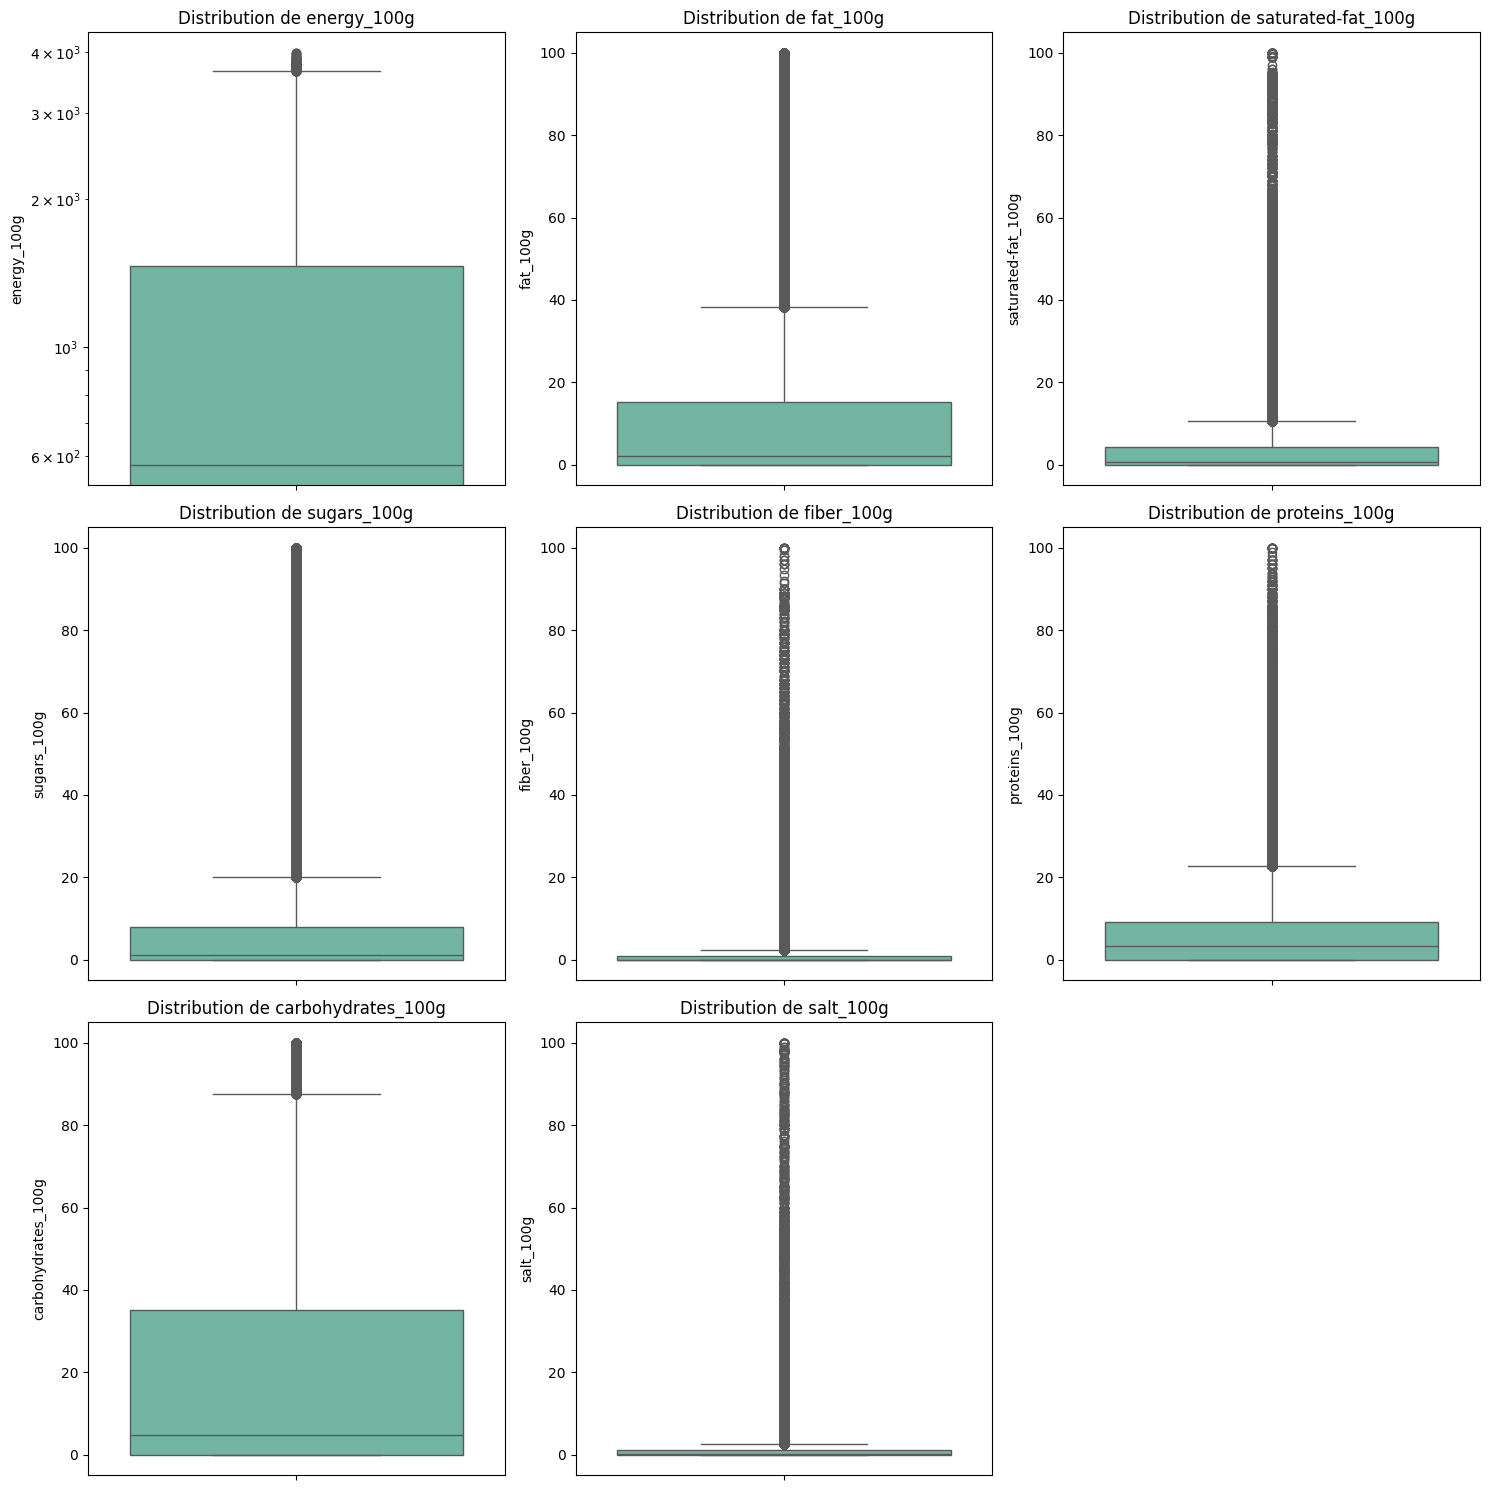

In [54]:
plot_outlier(df_cleaned)


Contrairement aux visualisations initiales, les distributions sont désormais contenues dans des limites physiquement cohérentes, ce qui assainit le signal pour le futur modèle :

*   **Respect des limites physiques :** Toutes les variables de masse (`fat_100g`, `sugars_100g`, `proteins_100g`, etc.) sont strictement comprises dans l'intervalle $[0, 100]$. L'énergie (`energy_100g`) est plafonnée à **4000 kJ**, éliminant les valeurs aberrantes à $10^9$ qui écrasaient la distribution précédemment.
*   **Visibilité des structures statistiques :** L'élimination des "méga-outliers" permet enfin d'observer la boîte centrale (représentant l'intervalle interquartile) et la médiane pour chaque nutriment. On note que la médiane de plusieurs variables se situe proche de zéro, ce qui reflète l'impact de la stratégie d'**imputation par zéro** choisie pour cette itération.
*   **Présence d'outliers "réalistes" :** Bien que des points isolés subsistent en haut des moustaches (notamment pour les fibres ou le sel), ils ne sont plus aberrants au sens physique du terme (ex: produits extrêmement salés). Le modèle de **Random Forest**, par sa nature robuste, sera capable de traiter ces valeurs extrêmes réelles sans perte de performance.

Cette étape de validation confirme que les données ont été correctement "normalisées" aux limites du monde physique, offrant une base acceptable pour la phase de modélisation.
